## Imports

In [1]:
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.spatial.distance import cdist
from scipy.stats import hypergeom, kendalltau, pearsonr, wilcoxon
from tqdm.notebook import tqdm

from analysis_helpers import Episode, Participant
from analysis_helpers.functions import (
    bootstrap_ci, 
    dtw,
    format_stats, 
    hypergeom_mc_test, 
    mean_center, 
    rank_biserial, 
    rdp, 
    show_source
)

## Functions

In [2]:
show_source(rdp)

In [3]:
show_source(dtw)

In [4]:
show_source(format_stats)

In [5]:
show_source(mean_center)

In [6]:
def hypergeom_z(tp_obs, pool_size, n_good, n_draws):
    """
    Z-score an observed true-positive count against a hypergeometric 
    distribution.
    
    Parameters
    ----------
    tp_obs : int
        Observed true-positive count (successful draws) to z-score.
    pool_size : int
        Number of items in the pool to draw from.
    n_good : int
        Number of "success" items in the pool.
    n_draws : int
        Number of draws to make from the pool, without replacement.
        
    Returns
    -------
    float
        Z-score for for the observed true-positive count.
    """
    mean, var = hypergeom.stats(pool_size, n_good, n_draws, moments='mv')
    return (tp_obs - mean) / np.sqrt(var)

## Load data

In [7]:
atlep1 = Episode('atlep1')
participants = Participant.load_all()

In [8]:
# center immediate & delayed recall on mean centroid to mitigate 
# person-specific register effects (idiolect, etc.)
imm_events_centered = []
del_events_centered = []
for p in participants:
    imm_centered, del_centered = mean_center(p.events['atlep1'], p.events['delayed'])
    imm_events_centered.append(imm_centered)
    del_events_centered.append(del_centered)

In [9]:
EPSILON_STEP = 0.01
EPSILONS = np.arange(0, 2, EPSILON_STEP).round(2)

df = pd.DataFrame(index=range(len(participants) * (len(EPSILONS))), 
                  columns=('participant', 
                           'epsilon', 
                           'n_events_removed', 
                           'n_events_remaining', 
                           'warp_cost'))
df['participant'] = np.repeat([f'P{p.sub_n}' for p in participants], len(EPSILONS))
df['epsilon'] = np.tile(EPSILONS, len(participants))

pbar = tqdm(total=len(df), leave=False)
df_ix = 0
for p_ix in range(len(participants)):
    imm_events = imm_events_centered[p_ix]
    del_events = del_events_centered[p_ix]

    # un-simplified alignment cost (baseline)
    n_events_orig = len(imm_events)
    n_events_remaining = n_events_orig
    n_events_removed = 0
    warp_cost = dtw(imm_events, del_events, metric='cosine', norm_cost=True)[0]
    df.loc[df_ix, 'n_events_removed':'warp_cost'] = (n_events_removed, 
                                                     n_events_remaining, 
                                                     warp_cost)
    df_ix += 1
    pbar.update()
    
    for epsilon in EPSILONS[1:]:
        imm_simplified = rdp(imm_events, epsilon=epsilon, metric='cosine')
        if len(imm_simplified) != n_events_remaining:
            n_events_remaining = len(imm_simplified)
            n_events_removed = n_events_orig - n_events_remaining
            warp_cost = dtw(imm_simplified, 
                            del_events, 
                            metric='cosine', 
                            norm_cost=True)[0]
        
        df.loc[df_ix, 'n_events_removed':'warp_cost'] = (n_events_removed, 
                                                         n_events_remaining, 
                                                         warp_cost)
        df_ix += 1
        pbar.update()
        
        if n_events_remaining == 2:
            last_p_row = df.index[df['participant'] == f'P{p_ix + 1}'][-1].item()
            df.loc[
                df_ix:last_p_row, 'n_events_removed':'warp_cost'
            ] = (n_events_removed, n_events_remaining, warp_cost)
            df_ix = last_p_row + 1
            pbar.update(df_ix - pbar.n)
            break
            
df = df.astype({'participant': str, 
                'epsilon': float, 
                'n_events_removed': int, 
                'n_events_remaining': int, 
                'warp_cost': float})
pbar.close()

  0%|          | 0/10600 [00:00<?, ?it/s]

In [10]:
best_alignments = (
    df.loc[
        df.groupby('participant')['warp_cost'].idxmin(), [
            'participant', 
            'epsilon', 
            'n_events_removed', 
            'n_events_remaining', 
            'warp_cost'
        ]
    ]
    .sort_values(
        by='participant', key=lambda pid: pid.str.removeprefix('P').astype(int)
    )
    .reset_index(drop=True)
)

best_alignments['n_events_imm'] = [len(p.events['atlep1']) for p in participants]
best_alignments['n_events_del'] = [len(p.events['delayed']) for p in participants]
best_alignments['n_events_decrease'] = best_alignments['n_events_imm'] - best_alignments['n_events_del']

best_alignments.head()

,participant,epsilon,n_events_removed,n_events_remaining,warp_cost,n_events_imm,n_events_del,n_events_decrease
0,P1,0.42,1,22,0.558993,23,19,4
1,P2,0.00,0,14,0.549072,14,16,-2
2,P3,0.29,1,19,0.468923,20,18,2
3,P4,0.00,0,19,0.397291,19,18,1
4,P5,0.00,0,18,0.466080,18,19,-1


best-fitting tolerance: median=0.00, range=[0.00, 0.82], zero for 27 of 53 participants
events removed at that tolerance: median=0, mean=1.00


<Axes: xlabel='epsilon', ylabel='Count'>

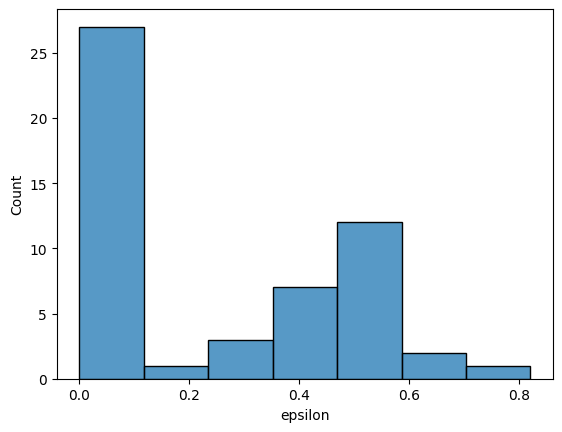

In [11]:
eps = best_alignments['epsilon']
removed = best_alignments['n_events_removed']

# ties in warp cost are resolved in favor of the smallest tolerance, so a zero
# here records the absence of an improvement rather than a positive fit at 0
print(f'best-fitting tolerance: median={eps.median():.2f}, '
      f'range=[{eps.min():.2f}, {eps.max():.2f}], '
      f'zero for {(eps == 0).sum()} of {len(eps)} participants')
print(f'events removed at that tolerance: median={removed.median():.0f}, '
      f'mean={removed.mean():.2f}')

sns.histplot(eps)

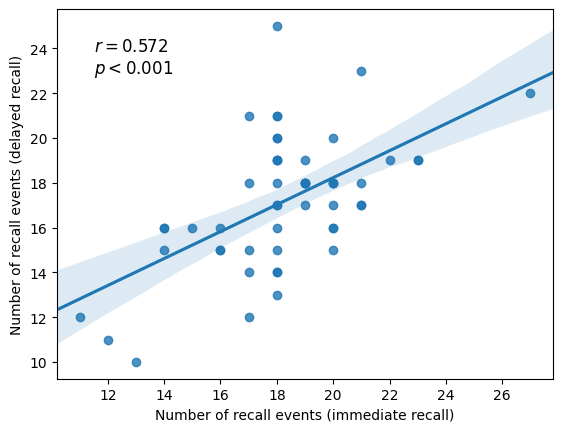

In [12]:
ax = sns.regplot(best_alignments, 
                 x='n_events_imm', 
                 y='n_events_del', 
                 truncate=False)
r, p = pearsonr(best_alignments['n_events_imm'], best_alignments['n_events_del'])
stats_fmt = format_stats(r, p, 'r')
ax.text(0.075, 0.925, 
        stats_fmt, 
        ha='left', 
        va='top', 
        transform=ax.transAxes, 
        fontsize=12)
ax.set_xlabel('Number of recall events (immediate recall)')
ax.set_ylabel('Number of recall events (delayed recall)')
plt.show()

tau=0.518, p=3.4601e-06, 95% CI [0.356, 0.658], n=53


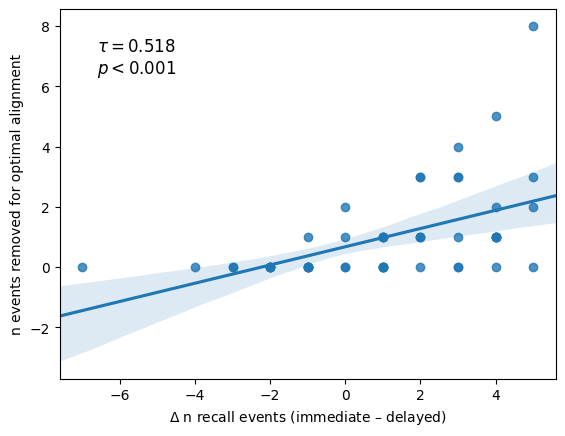

In [13]:
ax = sns.regplot(best_alignments, 
                 x='n_events_decrease',
                 y='n_events_removed', 
                 truncate=False)
tau, p = kendalltau(best_alignments['n_events_decrease'], 
                    best_alignments['n_events_removed'])
pairs = best_alignments[['n_events_decrease', 'n_events_removed']].to_numpy(dtype=float)
ci_lo, ci_hi = bootstrap_ci(pairs, lambda xy: kendalltau(xy[:, 0], xy[:, 1]).statistic)
print(f'tau={tau:.3f}, p={p:.4e}, 95% CI [{ci_lo:.3f}, {ci_hi:.3f}], '
      f'n={len(best_alignments)}')
stats_fmt = format_stats(tau, p, '\\tau')
ax.text(0.075, 0.925, 
        stats_fmt, 
        ha='left', 
        va='top', 
        transform=ax.transAxes, 
        fontsize=12)
ax.set_xlabel('$\\Delta$ n recall events (immediate – delayed)')
ax.set_ylabel('n events removed for optimal alignment')
plt.show()

tau=0.457, p=1.9037e-05, 95% CI [0.289, 0.608], n=53


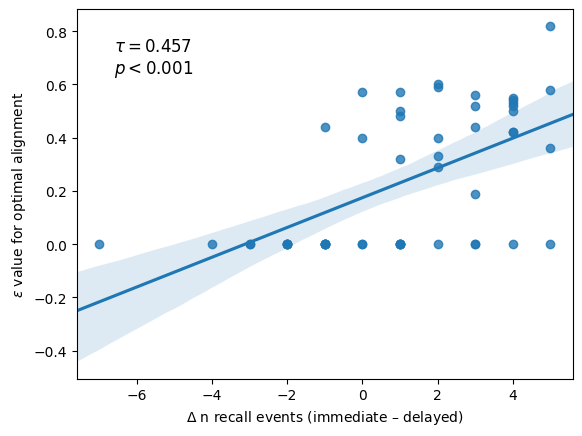

In [14]:
ax = sns.regplot(best_alignments, 
                 x='n_events_decrease', 
                 y='epsilon', 
                 truncate=False)
tau, p = kendalltau(best_alignments['n_events_decrease'], 
                    best_alignments['epsilon'])
pairs = best_alignments[['n_events_decrease', 'epsilon']].to_numpy(dtype=float)
ci_lo, ci_hi = bootstrap_ci(pairs, lambda xy: kendalltau(xy[:, 0], xy[:, 1]).statistic)
print(f'tau={tau:.3f}, p={p:.4e}, 95% CI [{ci_lo:.3f}, {ci_hi:.3f}], '
      f'n={len(best_alignments)}')
stats_fmt = format_stats(tau, p, '\\tau')
ax.text(0.075, 0.925, 
        stats_fmt, 
        ha='left', 
        va='top', 
        transform=ax.transAxes, 
        fontsize=12)
ax.set_xlabel('$\\Delta$ n recall events (immediate – delayed)')
ax.set_ylabel('$\\epsilon$ value for optimal alignment')
plt.show()

In [15]:
newcols = [
    'rdp_pred_forgotten', 
    'true_forgotten',
    'true_positives',
    'false_positives',
    'true_negatives',
    'false_negatives'
]
best_alignments[newcols] = np.nan
best_alignments[['rdp_pred_forgotten', 'true_forgotten']] = best_alignments[
    ['rdp_pred_forgotten', 'true_forgotten']
].astype(object)


for ix, row in best_alignments.iterrows():
    p = participants[ix]
    imm_events = imm_events_centered[ix]
    imm_event_matches = p.event_matches['atlep1']
    del_event_matches = p.event_matches['delayed']
    
    imm_simplified, rec_events_retained = rdp(imm_events, 
                                              epsilon=row['epsilon'], 
                                              metric='cosine', 
                                              return_indices=True)
    ep_events_dropped_rdp = np.delete(imm_event_matches, rec_events_retained)
    pred_forgotten = set(ep_events_dropped_rdp.tolist())
    # events should be deduplicated for analysis, but no duplicates 
    # actually exist in the first place:
    np.testing.assert_array_equal(sorted(ep_events_dropped_rdp), sorted(pred_forgotten))
    best_alignments.at[ix, 'rdp_pred_forgotten'] = pred_forgotten
    
    # exclude first & last immediate recall events since RDP will never
    # remove first or last point
    imm_rec_counts = Counter(imm_event_matches[1:-1].tolist())
    del_rec_counts = Counter(del_event_matches.tolist())
    true_forgotten = set((imm_rec_counts - del_rec_counts).keys())
    best_alignments.at[ix, 'true_forgotten'] = true_forgotten
    
    best_alignments.loc[ix, 'true_positives':'false_negatives'] = (
        # true pos: predicted forgotten & forgotten
        len(pred_forgotten & true_forgotten),
        # false pos: predicted forgotten & not forgotten
        len(pred_forgotten - true_forgotten),
        # true neg: not predicted forgotten & not forgotten
        len(set(imm_rec_counts.keys()) - true_forgotten - pred_forgotten),
        # false neg: forgotten & not predicted forgotten
        len(true_forgotten - pred_forgotten)
    )

best_alignments[
    ['true_positives', 'false_positives', 'true_negatives', 'false_negatives']
] = best_alignments[
    ['true_positives', 'false_positives', 'true_negatives', 'false_negatives']
].astype(int)

best_alignments.head()

,participant,epsilon,n_events_removed,n_events_remaining,warp_cost,n_events_imm,n_events_del,n_events_decrease,rdp_pred_forgotten,true_forgotten,true_positives,false_positives,true_negatives,false_negatives
0,P1,0.42,1,22,0.558993,23,19,4,{1},"{10, 4, 13}",0,1,14,3
1,P2,0.00,0,14,0.549072,14,16,-2,{},"{9, 12}",0,0,10,2
2,P3,0.29,1,19,0.468923,20,18,2,{9},"{9, 13}",1,0,16,1
3,P4,0.00,0,19,0.397291,19,18,1,{},"{13, 14}",0,0,14,2
4,P5,0.00,0,18,0.466080,18,19,-1,{},"{13, 4, 12}",0,0,13,3


PearsonRResult(statistic=np.float64(0.517581357686006), pvalue=np.float64(7.221205275103454e-05))

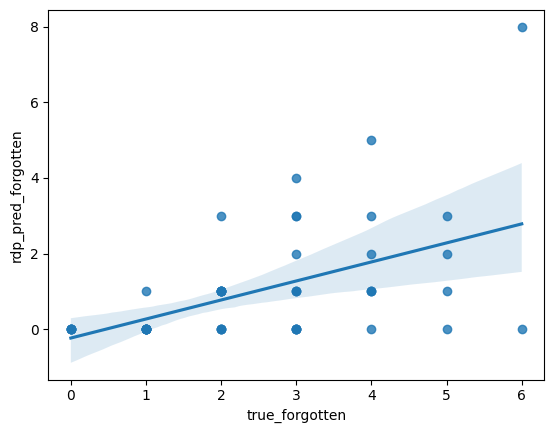

In [16]:
sns.regplot(x=best_alignments['true_forgotten'].apply(len), 
            y=best_alignments['rdp_pred_forgotten'].apply(len))
pearsonr(best_alignments['true_forgotten'].apply(len), best_alignments['rdp_pred_forgotten'].apply(len))

## Analysis 1

recall events correctly identified: 22 in total, against 12.9 expected by chance, p=7.9992e-04 (Monte Carlo test over 10,000 hypergeometric draws)
per participant: mean excess=0.172 events, 95% CI [0.064, 0.287], n=53


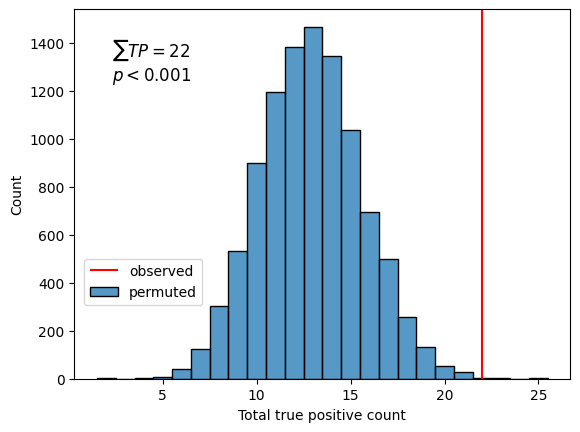

In [17]:
# number of immediate recall events (excluding endpoints)
n_imm_events = best_alignments.loc[:, 'true_positives':'false_negatives'].sum(axis=1).to_numpy()
# number of events actually forgotten
n_true_forgotten = best_alignments[['true_positives', 'false_negatives']].sum(axis=1).to_numpy()
# number of events predicted to be forgotten
n_pred_forgotten = best_alignments[['true_positives', 'false_positives']].sum(axis=1).to_numpy()

obs_tpsum, expected, p, null_tpsums = hypergeom_mc_test(
    n_true_forgotten, 
    n_imm_events - n_true_forgotten, 
    n_pred_forgotten, 
    best_alignments['true_positives']
)

# the excess over the analytic hypergeometric mean, for an effect size with an
# interval on it
expected_each = n_true_forgotten * n_pred_forgotten / n_imm_events
excess = best_alignments['true_positives'].to_numpy() - expected_each
ci_lo, ci_hi = bootstrap_ci(excess, np.mean)

print(f'recall events correctly identified: {obs_tpsum} in total, against '
      f'{expected:.1f} expected by chance, p={p:.4e} '
      f'(Monte Carlo test over {len(null_tpsums):,} hypergeometric draws)')
print(f'per participant: mean excess={excess.mean():.3f} events, '
      f'95% CI [{ci_lo:.3f}, {ci_hi:.3f}], n={len(participants)}')

ax = sns.histplot(null_tpsums, discrete=True, label='permuted')
ax.set_ylim(ax.get_ylim())
ax.vlines(obs_tpsum, *ax.get_ylim(), color='r', label='observed')
ax.legend(loc=(0.02, 0.2))
stats_fmt = format_stats(obs_tpsum, p, '\\sum TP', n_decimals_stat=0)
ax.text(0.075, 0.925, 
        stats_fmt, 
        ha='left', 
        va='top', 
        transform=ax.transAxes, 
        fontsize=12)
ax.set_xlabel('Total true positive count')
plt.show()

## Analysis 2

In [18]:
own_tp_zs = []
other_tp_zs = []
included_participants = []

for ix, row in best_alignments.iterrows():
    p = participants[ix]
    own_pred_forgotten = row['rdp_pred_forgotten']
    true_forgotten = row['true_forgotten']
    
    # only consider participants who actually forgot and were predicted 
    # to forget at least 1 event
    if len(own_pred_forgotten) == 0 or len(true_forgotten) == 0:
        continue
        
    own_tp = row['true_positives']
    pool = set(p.event_matches['atlep1'][1:-1])  # excluding endpoints
    own_tp_z = hypergeom_z(own_tp, 
                           len(pool), 
                           len(true_forgotten), 
                           len(own_pred_forgotten))
    own_tp_zs.append(own_tp_z)
    included_participants.append(p)
    
    _other_tp_zs = []
    for other_ix, other_row in best_alignments.iterrows():
        if other_ix == ix:
            continue
            
        # restrict predicted-forgotten events to those the target 
        # participant recalled (not-recalled events can't be predicted 
        # to be forgotten)
        other_pred_forgotten = other_row['rdp_pred_forgotten'] & pool
        # only consider surrogate participants who were predicted to 
        # forget at least 1 event the target participant recalled (and 
        # so could have forgotten) so own-predictions aren't competing 
        # against artificially poor other-predictions
        if len(other_pred_forgotten) == 0:
            continue
        
        other_tp = len(other_pred_forgotten & true_forgotten)
#         with warnings.catch_warnings():
#             warnings.simplefilter('error')
        other_tp_z = hypergeom_z(other_tp, 
                                 len(pool), 
                                 len(true_forgotten), 
                                 len(other_pred_forgotten))
        _other_tp_zs.append(other_tp_z)
        
    other_tp_zs.append(_other_tp_zs)
    
own_tp_zs = np.array(own_tp_zs)

pct_ranks = np.empty(len(own_tp_zs))
for i, own in enumerate(own_tp_zs):
    other = np.asarray(other_tp_zs[i])
    pct_ranks[i] = ((own > other).sum() + (own == other).sum() * 0.5) / len(other)

T, p = wilcoxon(pct_ranks, 0.5, alternative='greater')
r = rank_biserial(pct_ranks - 0.5)
ci_lo, ci_hi = bootstrap_ci(pct_ranks)

print(f'T={T.item()}, p={p.item():.4e} (one-sided), rank-biserial r={r:.3f}')
print(f'median percentile rank={np.median(pct_ranks):.3f}, '
      f'95% CI [{ci_lo:.3f}, {ci_hi:.3f}], n={len(included_participants)}')

T=272.0, p=7.1229e-03 (one-sided), rank-biserial r=0.550
median percentile rank=0.714, 95% CI [0.523, 0.840], n=26
